# Handling Missing Values in IRIS Dataset

This notebook demonstrates various methods for handling missing values in the IRIS dataset, including visualization, deletion, and imputation techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression

sns.set_style('whitegrid')

In [2]:
# Load sample Iris dataset
# Use IRIS.csv from workspace and inject missing values for demonstration
raw_df = pd.read_csv('IRIS.csv')
df = raw_df.copy()

np.random.seed(42)
missing_indices = np.random.choice(df.index, size=12, replace=False)
cols_to_mask = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for idx in missing_indices:
    col = np.random.choice(cols_to_mask)
    df.loc[idx, col] = np.nan

print('Loaded IRIS dataset and injected missing values for demonstration.')
print(f'Total missing values: {df.isnull().sum().sum()}')

Loaded IRIS dataset and injected missing values for demonstration.
Total missing values: 12


## Visualizing Missing Values

In [3]:
print('Dataset snapshot with missing values:')
print(df.head(10))

print('\nMissing values count by column:')
print(df.isnull().sum())

Dataset snapshot with missing values:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa
6           4.6          3.4           1.4          0.3  Iris-setosa
7           5.0          3.4           1.5          0.2  Iris-setosa
8           4.4          2.9           1.4          0.2  Iris-setosa
9           4.9          3.1           1.5          0.1  Iris-setosa

Missing values count by column:
sepal_length    3
sepal_width     0
petal_length    7
petal_width     2
species         0
dtype: int64


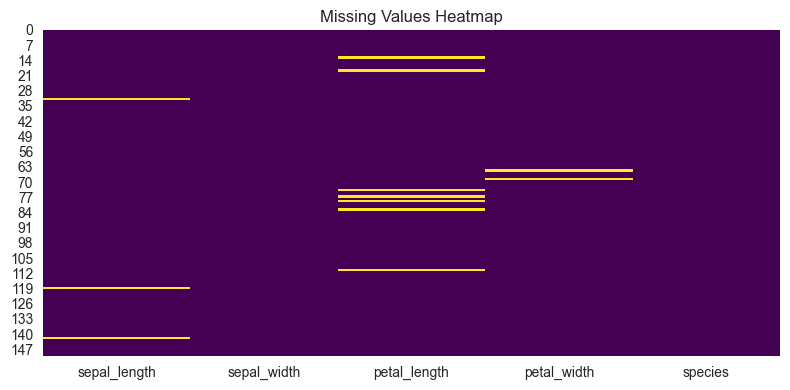

In [4]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

## Deletion Method

In [5]:
deleted_df = df.dropna()

print('After deletion, dataset shape: ', deleted_df.shape)
print('Missing values remaining:')
print(deleted_df.isnull().sum())
print('\nPreview of dataset after deletion:')
print(deleted_df.head())

After deletion, dataset shape:  (138, 5)
Missing values remaining:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Preview of dataset after deletion:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


## Imputation Methods

In [6]:
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 1. Mean Imputation
mean_imputed = df.copy()
mean_values = mean_imputed[numeric_cols].mean()
mean_imputed[numeric_cols] = mean_imputed[numeric_cols].fillna(mean_values)
print('Mean Imputation - first 5 rows:')
print(mean_imputed.head())
print('\nMissing values after mean imputation:')
print(mean_imputed.isnull().sum())

Mean Imputation - first 5 rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Missing values after mean imputation:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [7]:
# 2. Median Imputation
median_imputed = df.copy()
median_values = median_imputed[numeric_cols].median()
median_imputed[numeric_cols] = median_imputed[numeric_cols].fillna(median_values)
print('Median Imputation - first 5 rows:')
print(median_imputed.head())
print('\nMissing values after median imputation:')
print(median_imputed.isnull().sum())

Median Imputation - first 5 rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Missing values after median imputation:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [8]:
# 3. Mode Imputation
mode_imputed = df.copy()
for col in numeric_cols:
    mode_value = mode_imputed[col].mode()[0]
    mode_imputed[col] = mode_imputed[col].fillna(mode_value)
print('Mode Imputation - first 5 rows:')
print(mode_imputed.head())
print('\nMissing values after mode imputation:')
print(mode_imputed.isnull().sum())

Mode Imputation - first 5 rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Missing values after mode imputation:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
